<a href="https://colab.research.google.com/github/Zheltov/PT_ML/blob/main/PT_Transformer_HT1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Часть 1. Правильный attention

Пусть у нас есть текст "мама мыла раму" - он кодируется id своих токенов, допустим, [2, 5, 7].

### Self-Attention (пример: T = 3, D = 4)

$$
\begin{aligned}
&\textbf{Вход:} \\
&x = [2, 5, 7] \in \mathbb{R}^{3}
\\[6pt]
&\Downarrow \ \text{Embedding}
\\[6pt]
&X \in \mathbb{R}^{3 \times 4}
\\[12pt]
&\textbf{Линейные проекции:}
\\[6pt]
&X (3 \times 4)
\begin{cases}
\;\;\xrightarrow{\;\;W_Q (4 \times 4)\;\;} Q (3 \times 4) \\
\;\;\xrightarrow{\;\;W_K (4 \times 4)\;\;} K (3 \times 4) \\
\;\;\xrightarrow{\;\;W_V (4 \times 4)\;\;} V (3 \times 4)
\end{cases}
\\[16pt]
&\textbf{Attention:}
\\[6pt]
&Q (3 \times 4) \cdot K^\top (4 \times 3)
\;\;\longrightarrow\;\;
\text{scores} (3 \times 3)
\\[6pt]
&\Downarrow \ \text{softmax}
\\[6pt]
&\text{weights} (3 \times 3)
\\[12pt]
&\textbf{Контекст:}
\\[6pt]
&\text{weights} (3 \times 3) \cdot V (3 \times 4)
\;\;\longrightarrow\;\;
\text{context} (3 \times 4)
\\[16pt]
&\textbf{Выход:} \\
&\text{context} \in \mathbb{R}^{3 \times 4}
\end{aligned}
$$

In [9]:
# ====== SETUP ======
import torch
import torch.nn as nn
import torch.optim as optim
import math

# ====== DATA (разной длины) ======
raw_data = [
    # позитив (15)
    ("хорошо отлично", 1),
    ("прекрасно хорошо отлично", 1),
    ("замечательно великолепно отлично прекрасно", 1),
    ("чудесно отлично", 1),
    ("весьма хорошо прекрасно отлично", 1),
    ("супер классно отлично", 1),
    ("очень хорошо замечательно", 1),
    ("прекрасно довольно отлично", 1),
    ("хорошо весьма чудесно отлично", 1),
    ("замечательно супер хорошо", 1),
    ("очень прекрасно великолепно", 1),
    ("хорошо не плохо отлично", 1),          # tricky
    ("совсем не плохо прекрасно", 1),        # tricky
    ("весьма отлично и хорошо", 1),
    ("чудесно довольно прекрасно отлично", 1),

    # негатив (15)
    ("плохо ужасно", 0),
    ("ужасно плохо отвратительно", 0),
    ("отвратительно кошмарно", 0),
    ("жутко плохо", 0),
    ("совсем плохо ужасно отвратительно", 0),
    ("кошмарно очень плохо", 0),
    ("мерзко и ужасно", 0),
    ("плохо довольно жутко", 0),
    ("ужасно весьма отвратительно", 0),
    ("кошмарно плохо совсем", 0),
    ("не хорошо плохо", 0),                  # tricky
    ("совсем не хорошо", 0),                 # tricky
    ("очень плохо и ужасно", 0),
    ("жутко отвратительно плохо", 0),
    ("не прекрасно а плохо", 0)              # tricky
]

# ====== VOCAB ======
vocab = sorted(set(w for text, _ in raw_data for w in text.split()))
word2idx = {w: i+1 for i, w in enumerate(vocab)}  # 0 не используем
vocab_size = len(word2idx) + 1

def encode(text):
    return torch.tensor([word2idx[w] for w in text.split()], dtype=torch.long)

dataset = [(encode(t), torch.tensor([y])) for t, y in raw_data]

# ====== MODEL ======
class SelfAttentionSentiment(nn.Module):
    def __init__(self, vocab_size, embed_dim=16):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # здесь реализовать линейные слои W_Q, W_K, W_V
        self.W_Q = nn.Linear(embed_dim, embed_dim)
        self.W_K = nn.Linear(embed_dim, embed_dim)
        self.W_V = nn.Linear(embed_dim, embed_dim)

        self.cls = nn.Linear(embed_dim, 2)

    def forward(self, x):
        if x.dim() == 1:
            x = x.unsqueeze(0)

        # делаем эмбеддинг токена
        h = self.embed(x)

        # получаем матрицы Q, K, V, проецируя эмбеддинг на W_Q, W_K, W_V
        Q = self.W_Q(h)
        K = self.W_K(h)
        V = self.W_V(h)

        # считаем attention по Q, K, V
        scores = Q @ K.transpose(-2, -1) / math.sqrt(Q.size(-1))
        weights = torch.softmax(scores, dim=-1)
        context = weights @ V

        # считаем вектор текста как средний вектор attention-векторов слов
        c = context.mean(dim=1)

        # применяем классификатор (cls) к вектору текста и возвращаем прогноз и вектор весов внимания (сделано)
        return self.cls(c), weights

Запустим обучение по примерам (на каждой итерации подается очередной пример)

In [10]:

# ====== TRAIN ======
torch.manual_seed(42)

model = SelfAttentionSentiment(vocab_size)
opt = optim.Adam(model.parameters(), lr=0.02)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(300):
    total_loss = 0

    for x, y in dataset:
        x = x.unsqueeze(0)  # (1, T)
        y = y  # (1,)

        logits, _ = model(x)
        loss = loss_fn(logits, y)

        opt.zero_grad()
        loss.backward()
        opt.step()

        total_loss += loss.item()

    if epoch % 50 == 0:
        print(f"Epoch {epoch}: loss = {total_loss:.4f}")

# ====== EVAL ======
model.eval()
correct = 0

with torch.no_grad():
    for x, y in dataset:
        x = x.unsqueeze(0)
        logits, attn = model(x)
        pred = logits.argmax(1)

        correct += int(pred.item() == y.item())

print(f"\nAccuracy: {correct / len(dataset):.0%}")

# ====== INSPECT ATTENTION ======
i = 0
x, _ = dataset[i]
tokens = raw_data[i][0].split()

with torch.no_grad():
    _, attn = model(x.unsqueeze(0))

print("\nSentence:", tokens)
print("\nAttention matrix:")
print(attn[0])

Epoch 0: loss = 18.9758
Epoch 50: loss = 0.0022
Epoch 100: loss = 0.0004
Epoch 150: loss = 0.0001
Epoch 200: loss = 0.0001
Epoch 250: loss = 0.0000

Accuracy: 100%

Sentence: ['хорошо', 'отлично']

Attention matrix:
tensor([[1.4360e-06, 1.0000e+00],
        [2.4934e-07, 1.0000e+00]])


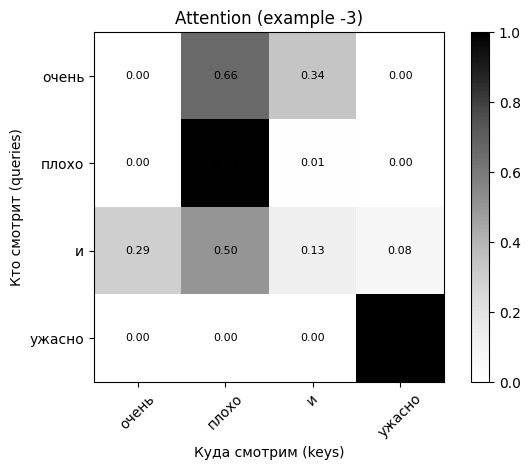

In [11]:
import matplotlib.pyplot as plt

i = -3  # любой индекс

x, _ = dataset[i]
tokens = raw_data[i][0].split()

with torch.no_grad():
    _, attn = model(x.unsqueeze(0))  # считаем ТОЛЬКО для этого примера

attn_matrix = attn[0].detach().cpu().numpy()
T = len(tokens)

plt.figure()
plt.imshow(attn_matrix, cmap="Greys", vmin=0, vmax=1)

plt.xticks(range(T), tokens, rotation=45)
plt.yticks(range(T), tokens)

plt.xlabel("Куда смотрим (keys)")
plt.ylabel("Кто смотрит (queries)")
plt.title(f"Attention (example {i})")

# подписи значений
for r in range(T):
    for c in range(T):
        plt.text(c, r, f"{attn_matrix[r, c]:.2f}",
                 ha='center', va='center', fontsize=8)

plt.colorbar()
plt.tight_layout()
plt.show()

# Часть 2. Multihead attention

### Multi-Head Self-Attention (пример: T = 3, D = 10, H = 5)

$$
\begin{aligned}
&\textbf{Вход:} \\
&x = [2, 5, 7] \in \mathbb{R}^{3}
\\[6pt]
&\Downarrow \ \text{Embedding}
\\[6pt]
&X \in \mathbb{R}^{3 \times 10}
\\[12pt]
&\textbf{Линейные проекции:}
\\[6pt]
&X (3 \times 10)
\begin{cases}
\;\;\xrightarrow{\;\;W_Q (10 \times 10)\;\;} Q (3 \times 10) \\
\;\;\xrightarrow{\;\;W_K (10 \times 10)\;\;} K (3 \times 10) \\
\;\;\xrightarrow{\;\;W_V (10 \times 10)\;\;} V (3 \times 10)
\end{cases}
\\[16pt]
&\textbf{Разбиение на головы (H = 5):}
\\[6pt]
&Q \rightarrow Q^{(1)}, \dots, Q^{(5)} \in \mathbb{R}^{3 \times 2}
\\
&K \rightarrow K^{(1)}, \dots, K^{(5)} \in \mathbb{R}^{3 \times 2}
\\
&V \rightarrow V^{(1)}, \dots, V^{(5)} \in \mathbb{R}^{3 \times 2}
\\[16pt]
&\textbf{Attention в каждой голове:}
\\[6pt]
&Q^{(h)} (3 \times 2) \cdot K^{(h)\top} (2 \times 3)
\;\;\longrightarrow\;\;
\text{scores}^{(h)} (3 \times 3)
\\[6pt]
&\Downarrow \ \text{softmax}
\\[6pt]
&\text{weights}^{(h)} (3 \times 3)
\\[6pt]
&\text{weights}^{(h)} \cdot V^{(h)} (3 \times 2)
\;\;\longrightarrow\;\;
\text{context}^{(h)} (3 \times 2)
\\[16pt]
&\textbf{Объединение голов:}
\\[6pt]
&\text{Concat}\left(
\text{context}^{(1)}, \dots, \text{context}^{(5)}
\right)
\;\;\longrightarrow\;\;
(3 \times 10)
\\[12pt]
&\xrightarrow{\;\;W_O (10 \times 10)\;\;}
\text{output} (3 \times 10)
\\[16pt]
&\textbf{Выход:} \\
&\text{output} \in \mathbb{R}^{3 \times 10}
\end{aligned}
$$

In [ ]:
class MultiHeadSelfAttentionSentiment(nn.Module):
    def __init__(self, vocab_size, embed_dim=16, num_heads=4):
        super().__init__()
        assert embed_dim % num_heads == 0

        # TODO: embedding слой
        self.embed = ...

        # TODO: сохранить число голов и размер одной головы
        self.num_heads = ...
        self.head_dim = ...

        # TODO: линейные проекции для Q, K, V
        self.W_Q = ...
        self.W_K = ...
        self.W_V = ...

        # TODO: проекция после объединения голов
        self.W_O = ...

        # TODO: классификатор
        self.cls = ...

    def split_heads(self, x):
        """
        (B, T, D) → (B, H, T, d)
        """
        B, T, D = x.shape

        # TODO: reshape в (B, T, H, d)
        x = ...

        # TODO: переставить оси → (B, H, T, d)
        x = ...

        return x

    def combine_heads(self, x):
        """
        (B, H, T, d) → (B, T, D)
        """
        B, H, T, d = x.shape

        # TODO: переставить оси → (B, T, H, d)
        x = ...

        # TODO: склеить головы → (B, T, D)
        x = ...

        return x

    def forward(self, x):
        """
        x: (B, T)
        """

        # TODO: embedding
        h = ...

        # TODO: получить Q, K, V
        Q = ...
        K = ...
        V = ...

        # TODO: разбить на головы
        Q = ...
        K = ...
        V = ...

        # TODO: вычислить scores (scaled dot-product attention)
        scores = ...

        # TODO: softmax по последней оси
        weights = ...

        # TODO: применить attention к V
        context = ...

        # TODO: объединить головы
        context = ...

        # TODO: линейная проекция после объединения
        context = ...

        # TODO: агрегировать по времени (например mean)
        c = ...

        # TODO: классификация
        logits = ...

        return logits, weights

In [ ]:
# ====== TRAIN ======
torch.manual_seed(42)
model = MultiHeadSelfAttentionSentiment(vocab_size)
opt = optim.Adam(model.parameters(), lr=0.02)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(300):
    logits, _ = model(X)
    loss = loss_fn(logits, Y)

    opt.zero_grad()
    loss.backward()
    opt.step()

# ====== EVAL ======
model.eval()
with torch.no_grad():
    logits, attn = model(X)
    acc = (logits.argmax(1) == Y).float().mean()

print(f"Accuracy: {acc:.0%}")

# ====== INSPECT ATTENTION ======
i = 0  # пример
tokens = raw_data[i][0].split()

print("\nSentence:", tokens)
print("\nAttention matrix (rows attend to columns):\n")
print(attn[i])

Accuracy: 100%

Sentence: ['хорошо', 'отлично']

Attention matrix (rows attend to columns):

tensor([[[3.0374e-02, 9.5911e-01, 1.0513e-02],
         [1.7119e-01, 4.6205e-02, 7.8261e-01],
         [1.9688e-01, 7.1992e-01, 8.3202e-02]],

        [[1.6054e-03, 9.9263e-01, 5.7670e-03],
         [1.6262e-06, 9.9998e-01, 1.8556e-05],
         [2.5380e-02, 9.2291e-01, 5.1710e-02]],

        [[4.6931e-03, 9.9476e-01, 5.5063e-04],
         [3.5379e-01, 4.9080e-01, 1.5540e-01],
         [3.2332e-01, 5.0576e-01, 1.7091e-01]],

        [[9.9996e-01, 2.2302e-05, 1.8005e-05],
         [9.9880e-01, 3.7409e-04, 8.2286e-04],
         [9.9877e-01, 5.6052e-04, 6.7212e-04]]])


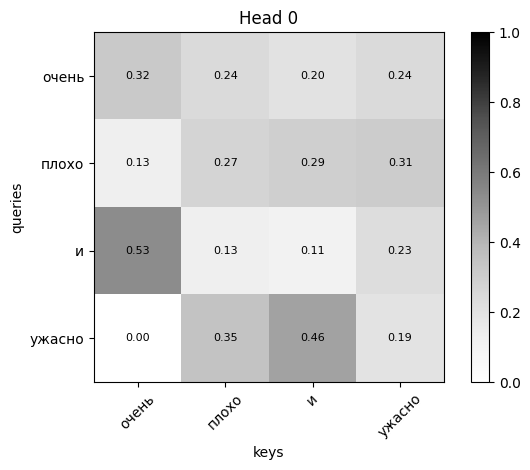

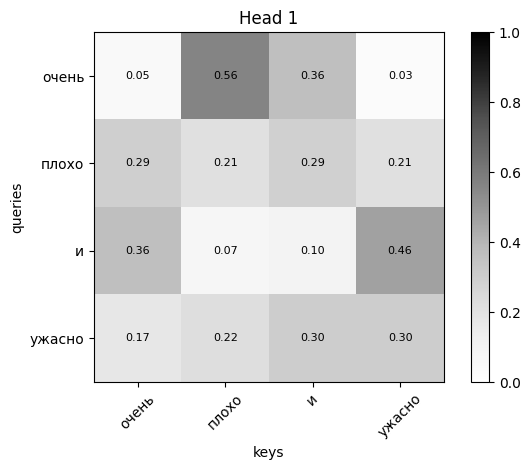

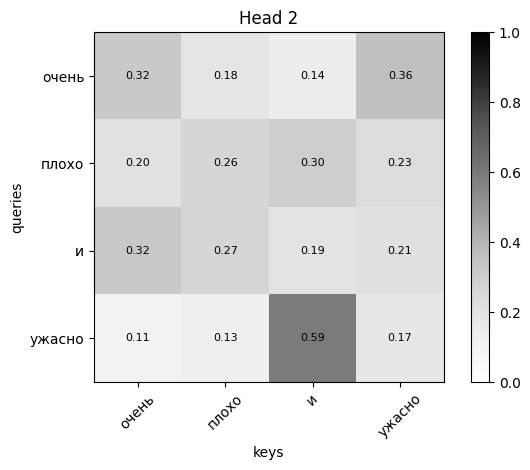

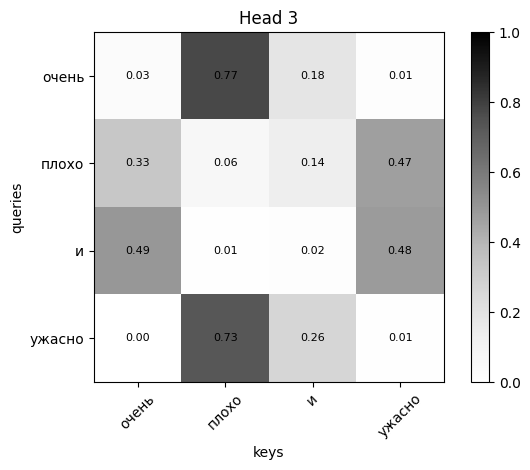

In [ ]:
import matplotlib.pyplot as plt

i = -3  # пример
x, _ = dataset[i]
tokens = raw_data[i][0].split()

with torch.no_grad():
    _, attn = model(x.unsqueeze(0))

attn = attn[0].detach().cpu().numpy()  # (H, T, T)
H, T, _ = attn.shape

for h in range(H):
    plt.figure()
    plt.imshow(attn[h], cmap="Greys", vmin=0, vmax=1)

    plt.xticks(range(T), tokens, rotation=45)
    plt.yticks(range(T), tokens)

    plt.title(f"Head {h}")
    plt.xlabel("keys")
    plt.ylabel("queries")

    for r in range(T):
        for c in range(T):
            plt.text(c, r, f"{attn[h, r, c]:.2f}",
                     ha='center', va='center', fontsize=8)

    plt.colorbar()
    plt.tight_layout()
    plt.show()